# An Exact and Robust Knapsack Framework for Fair Project Selection under Resource Uncertainty


It implements the project in four progressive stages:

1. **Data preparation**
2. **Baseline exact 0/1 knapsack**
3. **Fairness-aware exact knapsack**
4. **Robust fairness-aware exact knapsack under resource uncertainty**
5. **Monte Carlo evaluation and comparison**

The code is heavily commented so you can reuse it in your **report, viva, or presentation**.

## Step 1: Imports

We only use standard Python libraries plus NumPy, pandas, and matplotlib, which are already available in Colab.

In [1]:
import math
from functools import lru_cache
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Step 2: Create a sample project dataset

Each candidate project has:

- `project_id`: unique identifier
- `name`: project name
- `group`: fairness group/category
- `value`: utility/benefit score
- `base_cost`: nominal resource usage
- `uncertainty`: possible extra resource consumption
- `max_cost`: worst-case cost = base_cost + uncertainty

You can later replace this synthetic dataset with your own CSV.

In [2]:
# -------------------------------
# Create a reproducible toy dataset
# -------------------------------
projects = pd.DataFrame([
    {"project_id": 1,  "name": "Smart Attendance",        "group": "A", "value": 24, "base_cost": 8,  "uncertainty": 2},
    {"project_id": 2,  "name": "Crop Disease Detection", "group": "A", "value": 22, "base_cost": 7,  "uncertainty": 3},
    {"project_id": 3,  "name": "Medical Chatbot",        "group": "A", "value": 28, "base_cost": 11, "uncertainty": 4},
    {"project_id": 4,  "name": "Traffic Forecasting",    "group": "B", "value": 20, "base_cost": 6,  "uncertainty": 2},
    {"project_id": 5,  "name": "Library Recommender",    "group": "B", "value": 18, "base_cost": 5,  "uncertainty": 1},
    {"project_id": 6,  "name": "Energy Monitoring",      "group": "B", "value": 26, "base_cost": 9,  "uncertainty": 3},
    {"project_id": 7,  "name": "Disaster Alert",         "group": "C", "value": 25, "base_cost": 8,  "uncertainty": 2},
    {"project_id": 8,  "name": "Water Quality AI",       "group": "C", "value": 21, "base_cost": 7,  "uncertainty": 2},
    {"project_id": 9,  "name": "E-learning Analytics",   "group": "C", "value": 19, "base_cost": 6,  "uncertainty": 1},
    {"project_id": 10, "name": "Warehouse Robot",        "group": "D", "value": 30, "base_cost": 12, "uncertainty": 4},
    {"project_id": 11, "name": "Road Damage Detector",   "group": "D", "value": 23, "base_cost": 8,  "uncertainty": 2},
    {"project_id": 12, "name": "Waste Sorting Vision",   "group": "D", "value": 17, "base_cost": 5,  "uncertainty": 2},
])

projects["max_cost"] = projects["base_cost"] + projects["uncertainty"]
projects

,project_id,name,group,value,base_cost,uncertainty,max_cost
0,1,Smart Attendance,A,24,8,2,10
1,2,Crop Disease Detection,A,22,7,3,10
2,3,Medical Chatbot,A,28,11,4,15
3,4,Traffic Forecasting,B,20,6,2,8
4,5,Library Recommender,B,18,5,1,6
5,6,Energy Monitoring,B,26,9,3,12
6,7,Disaster Alert,C,25,8,2,10
7,8,Water Quality AI,C,21,7,2,9
8,9,E-learning Analytics,C,19,6,1,7
9,10,Warehouse Robot,D,30,12,4,16


### Optional: load your own CSV later

Expected columns:
- `project_id`
- `name`
- `group`
- `value`
- `base_cost`
- `uncertainty`

In [ ]:
# Example if you want to upload your own CSV in Colab:
#
# from google.colab import files
# uploaded = files.upload()
# projects = pd.read_csv("your_file_name.csv")
# projects["max_cost"] = projects["base_cost"] + projects["uncertainty"]
# projects.head()

## Step 3: Set problem parameters

- `BUDGET`: total available resource
- `fairness_requirements`: minimum number of selected projects from each group
- `alpha`: robustness level in [0, 1]
  - `0` = ignore uncertainty
  - `1` = fully conservative worst-case cost

In [3]:
BUDGET = 28

# Minimum representation from each group (fairness requirement)
# You can change these later.
fairness_requirements = {
    "A": 1,
    "B": 1,
    "C": 1,
    "D": 0,
}

alpha = 1.0

## Step 4: Helper functions

We need some utility functions for:
- summarizing a chosen solution
- counting selected groups
- computing total value and costs

In [4]:
def summarize_solution(selected_ids, data):
    # Create a dataframe containing only selected projects
    chosen = data[data["project_id"].isin(selected_ids)].copy().sort_values("project_id")

    # Compute totals
    total_value = int(chosen["value"].sum())
    total_base_cost = int(chosen["base_cost"].sum())
    total_max_cost = int(chosen["max_cost"].sum())

    # Group counts
    group_counts = chosen["group"].value_counts().to_dict()

    summary = {
        "selected_ids": list(chosen["project_id"]),
        "selected_names": list(chosen["name"]),
        "total_value": total_value,
        "total_base_cost": total_base_cost,
        "total_max_cost": total_max_cost,
        "group_counts": group_counts,
        "num_projects": len(chosen),
    }

    return chosen, summary


def print_summary(title, selected_ids, data):
    chosen, summary = summarize_solution(selected_ids, data)
    print("=" * 80)
    print(title)
    print("=" * 80)
    print(chosen[["project_id", "name", "group", "value", "base_cost", "uncertainty", "max_cost"]].to_string(index=False))
    print("-" * 80)
    print("Selected IDs       :", summary["selected_ids"])
    print("Total value        :", summary["total_value"])
    print("Total base cost    :", summary["total_base_cost"])
    print("Total worst cost   :", summary["total_max_cost"])
    print("Group counts       :", summary["group_counts"])
    print("Number of projects :", summary["num_projects"])
    print()

## Step 5: Baseline exact solver — classic 0/1 knapsack

This stage ignores fairness and uncertainty.

### Idea
Let `dp(i, b)` be the maximum value we can obtain using projects from index `i` onward with remaining budget `b`.

### Recurrence
- Skip project `i`
- Take project `i` if its cost fits

This returns the **exact optimal solution** for the deterministic baseline problem.

In [5]:
def exact_knapsack(data, budget, cost_column="base_cost"):
    items = data.reset_index(drop=True).copy()
    n = len(items)

    @lru_cache(maxsize=None)
    def dp(i, remaining_budget):
        # Base case: no items left
        if i == n:
            return 0

        # Option 1: skip current project
        best = dp(i + 1, remaining_budget)

        # Option 2: take current project if affordable
        cost = int(items.loc[i, cost_column])
        value = int(items.loc[i, "value"])

        if cost <= remaining_budget:
            best = max(best, value + dp(i + 1, remaining_budget - cost))

        return best

    def reconstruct():
        selected_ids = []
        remaining_budget = budget

        for i in range(n):
            skip_value = dp(i + 1, remaining_budget)
            cost = int(items.loc[i, cost_column])
            value = int(items.loc[i, "value"])

            take_value = -1
            if cost <= remaining_budget:
                take_value = value + dp(i + 1, remaining_budget - cost)

            # If taking matches the optimal value, we select it
            if take_value >= skip_value and take_value == dp(i, remaining_budget):
                selected_ids.append(int(items.loc[i, "project_id"]))
                remaining_budget -= cost

        return selected_ids

    best_value = dp(0, budget)
    selected_ids = reconstruct()
    return best_value, selected_ids

In [12]:
baseline_value, baseline_selected = exact_knapsack(projects, BUDGET, cost_column='base_cost')
print(f'Baseline optimal value: {baseline_value}')
_, summary = summarize_solution(baseline_selected, projects)
display(pd.DataFrame([summary]))

Baseline optimal value: 89


,selected_ids,selected_names,total_value,total_base_cost,total_max_cost,group_counts,num_projects
0,"[1, 2, 5, 7]","[Smart Attendance, Crop Disease Detection, Lib...",89,28,36,"{'A': 2, 'B': 1, 'C': 1}",4


## Step 6: Fairness-aware exact solver

Now we enforce minimum representation across groups.

### Example
If fairness requirements are:
- A >= 1
- B >= 1
- C >= 1

then the selected solution must contain at least one project from each required group.

### Exact DP state
We extend the state:
- `i`: current project index
- `b`: remaining budget
- counts of how many projects have already been selected from each required group

To keep the state space small, each group count is **capped** at its minimum requirement.  
For example, if group A needs at least 1 project, then:
- 0 means requirement not yet satisfied
- 1 means requirement already satisfied

In [6]:
def fair_exact_knapsack(data, budget, fairness_requirements, cost_column="base_cost"):
    items = data.reset_index(drop=True).copy()

    # Keep only groups that have a positive minimum requirement
    tracked_groups = [g for g, req in fairness_requirements.items() if req > 0]
    tracked_groups = sorted(tracked_groups)

    required = {g: int(fairness_requirements[g]) for g in tracked_groups}
    n = len(items)

    # Helper: cap a count so the state does not grow unnecessarily.
    # Example: if A needs at least 2, then states larger than 2 are equivalent for feasibility.
    def cap_count(group, count):
        return min(count, required[group])

    # Initial fairness state: all tracked group counts are 0
    initial_counts = tuple(0 for _ in tracked_groups)

    NEG_INF = -10**9

    @lru_cache(maxsize=None)
    def dp(i, remaining_budget, counts):
        counts = tuple(counts)

        # Base case: no items left
        if i == n:
            # Feasible only if all fairness requirements are satisfied
            for idx, g in enumerate(tracked_groups):
                if counts[idx] < required[g]:
                    return NEG_INF
            return 0

        # Option 1: skip current project
        best = dp(i + 1, remaining_budget, counts)

        # Option 2: take current project if cost fits
        cost = int(items.loc[i, cost_column])
        value = int(items.loc[i, "value"])
        group = items.loc[i, "group"]

        if cost <= remaining_budget:
            new_counts = list(counts)

            # If this project's group is tracked, update its count
            if group in tracked_groups:
                group_idx = tracked_groups.index(group)
                new_counts[group_idx] = cap_count(group, new_counts[group_idx] + 1)

            best = max(best, value + dp(i + 1, remaining_budget - cost, tuple(new_counts)))

        return best

    def reconstruct():
        selected_ids = []
        remaining_budget = budget
        counts = initial_counts

        for i in range(n):
            current_best = dp(i, remaining_budget, counts)
            skip_value = dp(i + 1, remaining_budget, counts)

            cost = int(items.loc[i, cost_column])
            value = int(items.loc[i, "value"])
            group = items.loc[i, "group"]

            take_value = NEG_INF
            new_counts = list(counts)

            if cost <= remaining_budget:
                if group in tracked_groups:
                    group_idx = tracked_groups.index(group)
                    new_counts[group_idx] = cap_count(group, new_counts[group_idx] + 1)

                take_value = value + dp(i + 1, remaining_budget - cost, tuple(new_counts))

            if take_value >= skip_value and take_value == current_best:
                selected_ids.append(int(items.loc[i, "project_id"]))
                remaining_budget -= cost
                counts = tuple(new_counts)

        return selected_ids

    best_value = dp(0, budget, initial_counts)

    if best_value < 0:
        return None, []

    selected_ids = reconstruct()
    return best_value, selected_ids

In [7]:
fair_value, fair_selected = fair_exact_knapsack(projects, BUDGET, fairness_requirements, cost_column="base_cost")

print("Fair exact optimal value:", fair_value)
print_summary("Fairness-Aware Exact Knapsack Solution", fair_selected, projects)

Fair exact optimal value: 89
Fairness-Aware Exact Knapsack Solution
 project_id                   name group  value  base_cost  uncertainty  max_cost
          1       Smart Attendance     A     24          8            2        10
          2 Crop Disease Detection     A     22          7            3        10
          5    Library Recommender     B     18          5            1         6
          7         Disaster Alert     C     25          8            2        10
--------------------------------------------------------------------------------
Selected IDs       : [1, 2, 5, 7]
Total value        : 89
Total base cost    : 28
Total worst cost   : 36
Group counts       : {'A': 2, 'B': 1, 'C': 1}
Number of projects : 4



## Step 7: Robust fairness-aware exact solver under resource uncertainty

Now each project has uncertain cost:
- nominal cost = `base_cost`
- extra uncertainty = `uncertainty`

We define a **robust effective cost** as:

\[
\text{robust_cost}_i = \lceil \text{base_cost}_i + \alpha \cdot \text{uncertainty}_i \rceil
\]

Where:
- `alpha = 0` means ignore uncertainty
- `alpha = 1` means fully conservative worst-case cost
- intermediate values provide partial robustness

Then we solve the fairness-aware exact knapsack using these robust costs.

In [8]:
def add_robust_cost(data, alpha):
    robust_data = data.copy()
    robust_data["robust_cost"] = np.ceil(
        robust_data["base_cost"] + alpha * robust_data["uncertainty"]
    ).astype(int)
    return robust_data

In [9]:
robust_projects = add_robust_cost(projects, alpha=alpha)
robust_projects[["project_id", "name", "group", "value", "base_cost", "uncertainty", "robust_cost"]]

,project_id,name,group,value,base_cost,uncertainty,robust_cost
0,1,Smart Attendance,A,24,8,2,10
1,2,Crop Disease Detection,A,22,7,3,10
2,3,Medical Chatbot,A,28,11,4,15
3,4,Traffic Forecasting,B,20,6,2,8
4,5,Library Recommender,B,18,5,1,6
5,6,Energy Monitoring,B,26,9,3,12
6,7,Disaster Alert,C,25,8,2,10
7,8,Water Quality AI,C,21,7,2,9
8,9,E-learning Analytics,C,19,6,1,7
9,10,Warehouse Robot,D,30,12,4,16


In [10]:
robust_value, robust_selected = fair_exact_knapsack(
    robust_projects,
    BUDGET,
    fairness_requirements,
    cost_column="robust_cost"
)

print("Robust fair exact optimal value:", robust_value)
print_summary("Robust Fair Exact Knapsack Solution", robust_selected, robust_projects)

Robust fair exact optimal value: 69
Robust Fair Exact Knapsack Solution
 project_id                name group  value  base_cost  uncertainty  max_cost
          1    Smart Attendance     A     24          8            2        10
          4 Traffic Forecasting     B     20          6            2         8
          7      Disaster Alert     C     25          8            2        10
--------------------------------------------------------------------------------
Selected IDs       : [1, 4, 7]
Total value        : 69
Total base cost    : 22
Total worst cost   : 28
Group counts       : {'A': 1, 'B': 1, 'C': 1}
Number of projects : 3



## Step 8: Compare baseline, fair, and robust-fair solutions

This makes the trade-off visible:
- Baseline usually gives the highest value
- Fairness can reduce value but improve representation
- Robust fairness can reduce nominal value further, but protects feasibility under uncertain resources

In [13]:
comparison = []

# Baseline
_, s1 = summarize_solution(baseline_selected, projects)
comparison.append({
    "model": "Baseline Exact",
    "total_value": s1["total_value"],
    "base_cost": s1["total_base_cost"],
    "worst_case_cost": s1["total_max_cost"],
    "num_projects": s1["num_projects"],
    "group_counts": str(s1["group_counts"]),
})

# Fair
_, s2 = summarize_solution(fair_selected, projects)
comparison.append({
    "model": "Fair Exact",
    "total_value": s2["total_value"],
    "base_cost": s2["total_base_cost"],
    "worst_case_cost": s2["total_max_cost"],
    "num_projects": s2["num_projects"],
    "group_counts": str(s2["group_counts"]),
})

# Robust Fair
_, s3 = summarize_solution(robust_selected, projects)
comparison.append({
    "model": "Robust Fair Exact",
    "total_value": s3["total_value"],
    "base_cost": s3["total_base_cost"],
    "worst_case_cost": s3["total_max_cost"],
    "num_projects": s3["num_projects"],
    "group_counts": str(s3["group_counts"]),
})

comparison_df = pd.DataFrame(comparison)
display(comparison_df)

,model,total_value,base_cost,worst_case_cost,num_projects,group_counts
0,Baseline Exact,89,28,36,4,"{'A': 2, 'B': 1, 'C': 1}"
1,Fair Exact,89,28,36,4,"{'A': 2, 'B': 1, 'C': 1}"
2,Robust Fair Exact,69,22,28,3,"{'A': 1, 'B': 1, 'C': 1}"


## Step 9: Monte Carlo evaluation

This is important for your report.

Even if baseline uses low nominal cost, it may violate the budget when real costs increase.  
The robust model is usually more conservative, but it should have a much lower violation rate.

We simulate random realized costs:

\[
\text{realized_cost}_i = \text{base_cost}_i + U(0, \text{uncertainty}_i)
\]

We then compare:
- average realized total cost
- budget violation rate
- average realized value (if you want to extend the model)

In [14]:
def monte_carlo_budget_violation(data, selected_ids, budget, num_trials=5000, seed=42):
    rng = np.random.default_rng(seed)
    chosen = data[data["project_id"].isin(selected_ids)].copy()

    realized_totals = []

    for _ in range(num_trials):
        realized_costs = chosen["base_cost"].to_numpy() + rng.uniform(
            0,
            chosen["uncertainty"].to_numpy()
        )
        realized_totals.append(realized_costs.sum())

    realized_totals = np.array(realized_totals)

    return {
        "mean_realized_cost": realized_totals.mean(),
        "std_realized_cost": realized_totals.std(),
        "violation_rate": np.mean(realized_totals > budget),
        "max_realized_cost": realized_totals.max(),
        "min_realized_cost": realized_totals.min(),
        "samples": realized_totals,
    }

In [15]:
mc_baseline = monte_carlo_budget_violation(projects, baseline_selected, BUDGET)
mc_fair = monte_carlo_budget_violation(projects, fair_selected, BUDGET)
mc_robust = monte_carlo_budget_violation(projects, robust_selected, BUDGET)

mc_df = pd.DataFrame([
    {"model": "Baseline Exact", "mean_realized_cost": mc_baseline["mean_realized_cost"],
     "std_realized_cost": mc_baseline["std_realized_cost"], "violation_rate": mc_baseline["violation_rate"]},
    {"model": "Fair Exact", "mean_realized_cost": mc_fair["mean_realized_cost"],
     "std_realized_cost": mc_fair["std_realized_cost"], "violation_rate": mc_fair["violation_rate"]},
    {"model": "Robust Fair Exact", "mean_realized_cost": mc_robust["mean_realized_cost"],
     "std_realized_cost": mc_robust["std_realized_cost"], "violation_rate": mc_robust["violation_rate"]},
])

mc_df

,model,mean_realized_cost,std_realized_cost,violation_rate
0,Baseline Exact,31.997009,1.219242,1.0
1,Fair Exact,31.997009,1.219242,1.0
2,Robust Fair Exact,24.991716,1.003601,0.0


## Step 10: Plot the comparison

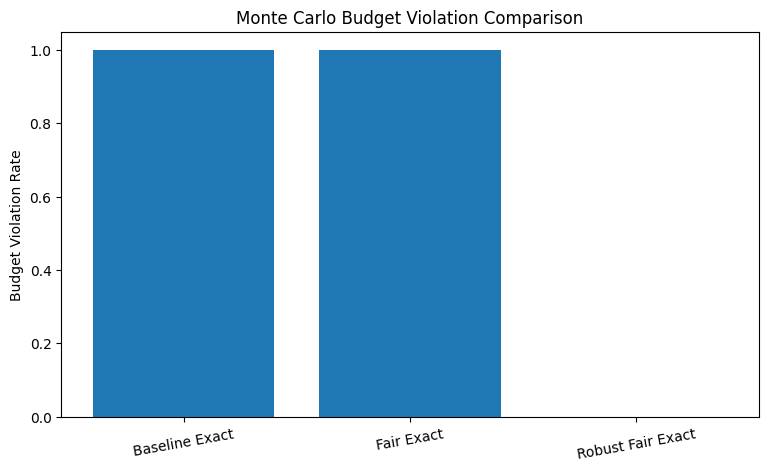

In [16]:
plt.figure(figsize=(9, 5))
plt.bar(mc_df["model"], mc_df["violation_rate"])
plt.ylabel("Budget Violation Rate")
plt.title("Monte Carlo Budget Violation Comparison")
plt.xticks(rotation=10)
plt.show()

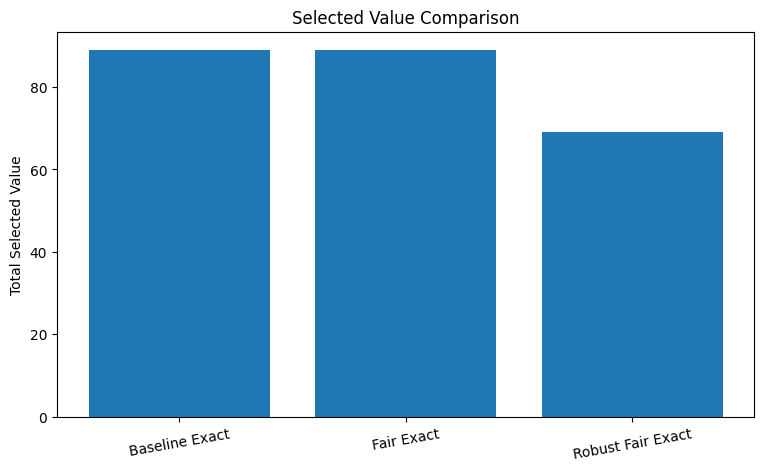

In [17]:
plt.figure(figsize=(9, 5))
plt.bar(comparison_df["model"], comparison_df["total_value"])
plt.ylabel("Total Selected Value")
plt.title("Selected Value Comparison")
plt.xticks(rotation=10)
plt.show()

## Step 11: Sensitivity analysis over robustness level

We now vary `alpha` from 0 to 1.

This shows the value–robustness trade-off:
- low alpha -> aggressive solution
- high alpha -> safer solution

In [18]:
alphas = np.linspace(0, 1, 6)
rows = []

for a in alphas:
    temp = add_robust_cost(projects, alpha=float(a))

    value, selected = fair_exact_knapsack(
        temp,
        BUDGET,
        fairness_requirements,
        cost_column="robust_cost"
    )

    if selected:
        _, summary = summarize_solution(selected, temp)
        mc = monte_carlo_budget_violation(projects, selected, BUDGET, num_trials=2000, seed=123)

        rows.append({
            "alpha": float(a),
            "selected_value": summary["total_value"],
            "base_cost": summary["total_base_cost"],
            "worst_case_cost": summary["total_max_cost"],
            "violation_rate": mc["violation_rate"],
            "num_projects": summary["num_projects"],
            "selected_ids": str(summary["selected_ids"]),
        })

sensitivity_df = pd.DataFrame(rows)
sensitivity_df

,alpha,selected_value,base_cost,worst_case_cost,violation_rate,num_projects,selected_ids
0,0.0,89,28,36,1.000,4,"[1, 2, 5, 7]"
1,0.2,79,24,31,0.323,4,"[2, 4, 5, 9]"
2,0.4,78,24,30,0.133,4,"[1, 5, 9, 12]"
3,0.6,69,22,28,0.000,3,"[1, 4, 7]"
4,0.8,69,22,28,0.000,3,"[1, 4, 7]"
5,1.0,69,22,28,0.000,3,"[1, 4, 7]"


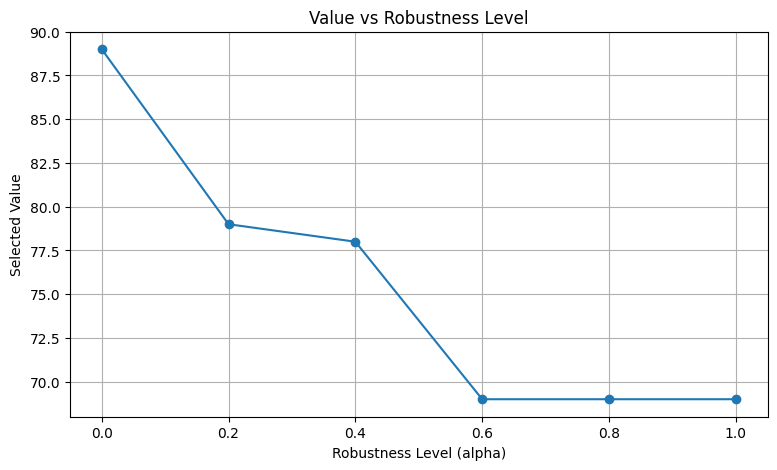

In [19]:
plt.figure(figsize=(9, 5))
plt.plot(sensitivity_df["alpha"], sensitivity_df["selected_value"], marker="o")
plt.xlabel("Robustness Level (alpha)")
plt.ylabel("Selected Value")
plt.title("Value vs Robustness Level")
plt.grid(True)
plt.show()

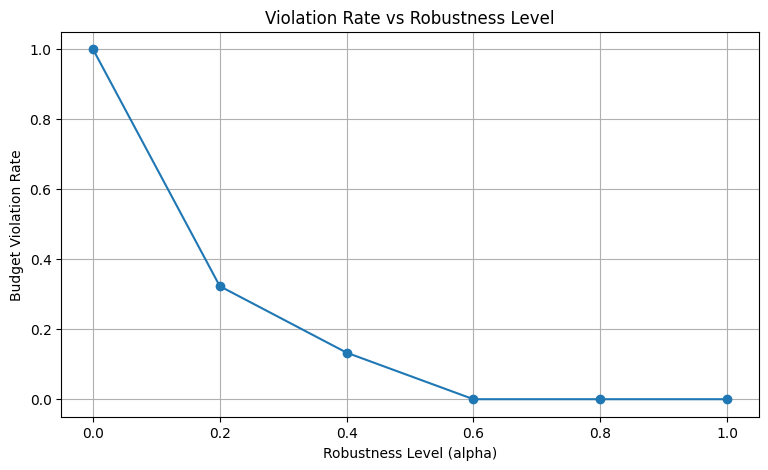

In [20]:
plt.figure(figsize=(9, 5))
plt.plot(sensitivity_df["alpha"], sensitivity_df["violation_rate"], marker="o")
plt.xlabel("Robustness Level (alpha)")
plt.ylabel("Budget Violation Rate")
plt.title("Violation Rate vs Robustness Level")
plt.grid(True)
plt.show()

## Step 12: Complexity analysis

### 1) Baseline exact knapsack
State:
- item index `i`
- remaining budget `b`

Number of states:
\[
O(nB)
\]

Time complexity:
\[
O(nB)
\]

Space complexity:
\[
O(nB)
\]
with memoization table.  
Iterative optimization can reduce space to:
\[
O(B)
\]

### 2) Fairness-aware exact knapsack
If tracked groups are \(g_1, g_2, ..., g_k\) with minimum requirements \(r_1, r_2, ..., r_k\), then the number of fairness states is:

\[
\prod_{j=1}^{k} (r_j + 1)
\]

So the total complexity becomes:

\[
O\left(nB \prod_{j=1}^{k} (r_j + 1)\right)
\]

Space complexity is of the same order with memoization.

### 3) Robust fair exact knapsack
If robustness is handled only by replacing nominal cost with robust effective cost, the asymptotic DP complexity remains the same as the fairness-aware case:

\[
O\left(nB \prod_{j=1}^{k} (r_j + 1)\right)
\]

The additional overhead for computing robust costs is:
\[
O(n)
\]

This is a strong result for your report:
**robustness improves feasibility under uncertainty without changing the DP order of complexity**.

## Step 13: Short interpretation for your report

Typical result pattern:
- **Baseline exact solution** gives the highest nominal value.
- **Fair exact solution** ensures representation across groups.
- **Robust fair exact solution** usually sacrifices some value, but greatly reduces budget violation under uncertainty.

This demonstrates the trade-off among:
- efficiency
- fairness
- robustness

## Step 14: Suggested next extensions

You can turn this into a stronger advanced project by adding:

1. **Group upper bounds** as well as lower bounds
2. **Priority weights** for special project categories
3. **Scenario-based uncertainty**
4. **Chance-constrained selection**
5. **Comparison with greedy or genetic algorithm**
6. **Real CSV dataset from your department/lab**

## Step 15: One-paragraph method description for your report

We formulate fair project selection as an exact 0/1 knapsack optimization problem with additional fairness constraints and uncertain resource usage. First, a deterministic exact dynamic programming model is used to maximize total project value under a fixed resource budget. Next, minimum group-wise representation constraints are incorporated into the dynamic programming state to ensure fairness in project selection. Finally, robustness is introduced by replacing nominal project costs with uncertainty-adjusted effective costs, enabling the model to remain feasible under adverse resource realizations. The resulting framework allows a systematic comparison of efficiency, fairness, and robustness while preserving an exact dynamic programming backbone.